In [2]:
import rich
import logging
import glob
import matplotlib.pyplot as plt
import time
import re
import os
import awkward as ak
import numpy as np
import pandas as pd
import json 
import yaml

import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from pathlib import Path
from collections import defaultdict
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch
import matplotlib as mpl
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)

# detector, runs and measure

In [5]:
detector = "V03421A"
run = "r001"

# path to HIT DATA

In [8]:
measurement_files = sorted(glob.glob(
    #f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.1.0/generated/tier/hit/{detector}/c1/*"
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/{detector}/c1/*"
))

print(*measurement_files, sep="\n")

/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_lat_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_lat_ssh
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS1_top_ssh
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS6_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/am_HS6_top_hvs
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/ba_HS4_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/bkg
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/V03421A/c1/co_HS5_top_hvs
/global/cfs/cdirs/m26

In [9]:
measurements = [
    os.path.basename(path)
    for path in measurement_files
]

print(measurements)

['am_HS1_lat_dlt', 'am_HS1_lat_ssh', 'am_HS1_top_dlt', 'am_HS1_top_ssh', 'am_HS6_top_dlt', 'am_HS6_top_hvs', 'ba_HS4_top_dlt', 'bkg', 'co_HS5_top_hvs', 'th_HS2_lat_psa', 'th_HS2_top_psa']


In [10]:
measure = "am_HS6_top_dlt"

In [11]:
file_names = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.1.0/generated/tier/hit/{detector}/c1/{measure}/char_data-{detector}-{measure}-{run}-*.lh5"
))[:10]

# for all the runs
# file_names = sorted(glob.glob(
   # f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/tier/hit/{detector}/c1/{measure}/*.lh5"
#))



In [12]:
len(file_names)

10

# path METAD DATA

In [13]:
file_meta = f"/global/cfs/cdirs/m2676/data/teststands/hades/daq/{detector}/c1/{measure}/meta/char_data-{detector}-{measure}-run0001.json"


In [14]:
#with open(file_meta, "r") as f:
#    metadata = json.load(f)

#print(json.dumps(metadata, indent=4))

# DATA

In [15]:
data = lh5.read("hit", file_names)

In [16]:
df = data.view_as("pd")
df.head()

,AoE_Classifier,AoE_Corrected,AoE_Double_Sided_Cut,AoE_High_Side_Cut,AoE_Low_Cut,LQ_Classifier,LQ_Cut,bl_pileup_cut,bl_pileup_cut_classifier,cuspEmax_cal,...,tail_pileup_cut,tail_pileup_cut_classifier,timestamp,tp_0_est,trapEmax_cal,trapEmax_ctc_cal,trapEmax_noctc_cal,zacEmax_cal,zacEmax_ctc_cal,zacEmax_noctc_cal
0,7.920776,1.106627,False,False,True,-63.779941,True,True,0.573331,60.171214,...,True,-0.763325,1.710496e+09,29280.0,60.065130,60.065130,60.061801,60.148574,60.148574,60.144903
1,15.629673,1.224146,False,False,True,968.405781,False,True,-0.847981,9.939467,...,True,0.976060,1.710496e+09,29728.0,10.286101,10.286526,10.286101,9.614002,9.614438,9.614002
2,-42.635472,0.425786,False,True,False,196.158773,False,True,-0.615314,42.204056,...,True,2.129597,1.710496e+09,29440.0,42.236502,42.238222,42.236502,42.531702,42.533611,42.531702
3,6.993160,1.094139,False,False,True,-21.366864,True,True,0.272305,60.846985,...,True,-0.527712,1.710496e+09,29440.0,60.922422,60.922422,60.919719,60.747540,60.747540,60.744571
4,-17.593428,0.763124,False,True,False,83.139028,False,True,-0.689680,50.085513,...,True,1.140516,1.710496e+09,29376.0,50.187675,50.187675,50.185156,49.922891,49.925651,49.922891


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6185868 entries, 0 to 6185867
Data columns (total 69 columns):
 #   Column                                 Dtype  
---  ------                                 -----  
 0   AoE_Classifier                         float64
 1   AoE_Corrected                          float64
 2   AoE_Double_Sided_Cut                   bool   
 3   AoE_High_Side_Cut                      bool   
 4   AoE_Low_Cut                            bool   
 5   LQ_Classifier                          float64
 6   LQ_Cut                                 bool   
 7   bl_pileup_cut                          bool   
 8   bl_pileup_cut_classifier               float64
 9   cuspEmax_cal                           float64
 10  cuspEmax_ctc_cal                       float64
 11  cuspEmax_noctc_cal                     float64
 12  daqenergy_cal                          int64  
 13  dt_eff                                 float64
 14  is_discharge                           bool   
 15  is_downgo

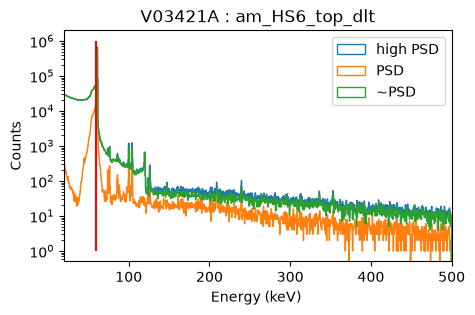

In [22]:
E_noQC = df["cuspEmax_ctc_cal"]
mask_clean = (
    ~df["is_discharge"]
    & df["is_positive_polarity_candidate"]
)



mask_highPSD = (mask_clean & df["AoE_High_Side_Cut"])
mask_PSD = (mask_clean & df["AoE_Double_Sided_Cut"])
mask_noPSD = (mask_clean & ~df["AoE_Double_Sided_Cut"])


E = df.loc[mask_clean, "cuspEmax_ctc_cal"]
bins = 1000


emin = 20
emax = 500


plt.figure(figsize=(5,3))
'''
plt.hist(
    E_noQC,
    bins=bins,
    histtype = 'step',
    range = (emin, emax),
    label=f"no QC ({len(E_noQC) * 100 / len(E_noQC):.1f} %)"
)


plt.hist(
    E,
    bins=bins,
    histtype = 'step',
    range = (emin, emax),
    label=f"no QC ({len(E) * 100 / len(E_noQC):.1f} %)"
)'''

plt.hist(
    df.loc[mask_highPSD, "cuspEmax_ctc_cal"],
    bins=bins,
    histtype = 'step',
    range = (emin, emax),
    label=f"high PSD"
)

plt.hist(
    df.loc[mask_PSD, "cuspEmax_ctc_cal"],
    bins=bins,
    histtype = 'step',
    range = (emin, emax),
    label=f"PSD"
)

plt.hist(
    df.loc[mask_noPSD, "cuspEmax_ctc_cal"],
    bins=bins,
    histtype = 'step',
    range = (emin, emax),
    label=f"~PSD"
)

plt.vlines(59, 1, 1e6, color = 'red')
plt.xlim(emin, emax)
plt.legend()
plt.title(f"{detector} : {measure}")
plt.xlabel("Energy (keV) ")
plt.ylabel("Counts")
plt.yscale('log')

Text(0, 0.5, 'Counts')

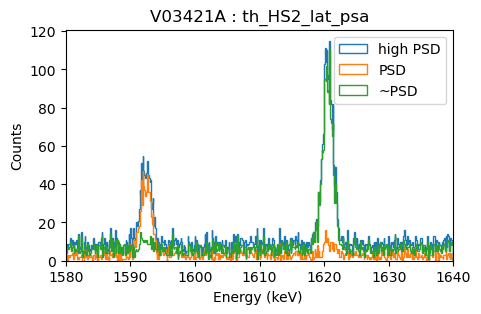

In [18]:
E_noQC = df["cuspEmax_ctc_cal"]
mask_clean = (
    ~df["is_discharge"]
    & df["is_positive_polarity_candidate"]
)



mask_highPSD = (mask_clean & df["AoE_High_Side_Cut"])
mask_PSD = (mask_clean & df["AoE_Double_Sided_Cut"])
mask_noPSD = (mask_clean & ~df["AoE_Double_Sided_Cut"])


E = df.loc[mask_clean, "cuspEmax_ctc_cal"]
bins = 500


emin = 1580
emax = 1640


plt.figure(figsize=(5,3))
'''
plt.hist(
    E_noQC,
    bins=bins,
    histtype = 'step',
    range = (emin, emax),
    label=f"no QC ({len(E_noQC) * 100 / len(E_noQC):.1f} %)"
)


plt.hist(
    E,
    bins=bins,
    histtype = 'step',
    range = (emin, emax),
    label=f"no QC ({len(E) * 100 / len(E_noQC):.1f} %)"
)'''

plt.hist(
    df.loc[mask_highPSD, "cuspEmax_ctc_cal"],
    bins=bins,
    histtype = 'step',
    range = (emin, emax),
    label=f"high PSD"
)

plt.hist(
    df.loc[mask_PSD, "cuspEmax_ctc_cal"],
    bins=bins,
    histtype = 'step',
    range = (emin, emax),
    label=f"PSD"
)

plt.hist(
    df.loc[mask_noPSD, "cuspEmax_ctc_cal"],
    bins=bins,
    histtype = 'step',
    range = (emin, emax),
    label=f"~PSD"
)


plt.xlim(emin, emax)
plt.legend()
plt.title(f"{detector} : {measure}")
plt.xlabel("Energy (keV) ")
plt.ylabel("Counts")
#plt.yscale('log')

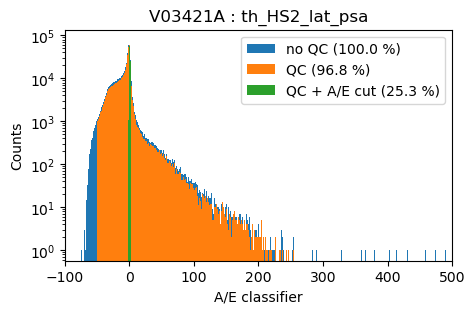

In [19]:
AoE_noQC = df["AoE_Classifier"]
mask_clean = (
    ~df["is_discharge"]
    & df["is_positive_polarity_candidate"]
)
AoE_hit = df.loc[mask_clean, "AoE_Classifier"]
m = (mask_clean & df["AoE_Double_Sided_Cut"])
AoE = df.loc[m, "AoE_Classifier"]
bins = 1000
plt.figure(figsize=(5,3))
plt.hist(
    AoE_noQC,
    bins=bins,
    range=(-100, 500),
    label=f"no QC ({len(AoE_noQC) * 100 / len(AoE_noQC):.1f} %)"
)
plt.hist(
    AoE_hit,
    bins=bins,
    range=(-50, 500),
    label=f"QC ({len(AoE_hit) * 100 / len(AoE_noQC):.1f} %)"
)
plt.hist(
    AoE,
    bins=bins,
    range=(-100, 500),
    label=f"QC + A/E cut ({len(AoE) * 100 / len(AoE_noQC):.1f} %)"
)
plt.xlim(-100, 500 )
plt.legend()
plt.title(f"{detector} : {measure}")
plt.xlabel("A/E classifier")
plt.ylabel("Counts")
plt.yscale('log')

# from sofia slides 3 dec 2025

dai dati plt possiamo ottener altrre informazioni su come si distirbuiscono i quality cut. 

sono informazioni già salvate nei file in DIZIONARIO; sono contenuti anche i plot

In [20]:
detector = "V03421A"

In [21]:
measurement_files = sorted(glob.glob(f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/plt/hit/{detector}/c1/th_HS2_lat_psa/char_data-{detector}-*"
))

print(*measurement_files, sep="\n")

/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/plt/hit/V03421A/c1/th_HS2_lat_psa/char_data-V03421A-th_HS2_lat_psa-r001-20240314T145644Z-plt_hit.pkl


In [22]:
df = pd.read_pickle(measurement_files[0])
df

{'qc': {'bl_pileup_cut': <Figure size 640x480 with 1 Axes>,
  'tail_pileup_cut': <Figure size 640x480 with 1 Axes>,
  'is_valid_bl_slope': <Figure size 640x480 with 1 Axes>,
  'is_valid_bl_slope_rms': <Figure size 640x480 with 1 Axes>,
  'is_valid_tail_rms': <Figure size 640x480 with 1 Axes>},
 'common': {'baseline_spectrum': {'bl_array': array([  0.,   0.,   0., ..., 148., 149., 144.], shape=(999,)),
   'bins': array([-499.5, -498.5, -497.5, ...,  496.5,  497.5,  498.5], shape=(999,))},
  'baseline_stability': {'time': array([1.71042453e+09, 1.71042471e+09, 1.71042489e+09, ...,
          1.71048519e+09, 1.71048537e+09, 1.71048555e+09], shape=(340,)),
   'baseline': array([16174.42382812,            nan,            nan, ...,
                     nan,            nan, 16129.50488281], shape=(340,)),
   'spread': array([316.8070623 ,          nan,          nan, ...,          nan,
                   nan, 165.22490968], shape=(340,))},
  'cuspEmax_ctc_cal': {'spectrum': {'bins': array([2.50

In [23]:
df['ecal']['cuspEmax_ctc_cal'].keys()

dict_keys(['fwhm_fit', 'cal_fit', 'peak_fits', 'spectrum', 'survival_frac', '2614_stability', '583_stability', '2614_timemap', 'pulser_timemap'])

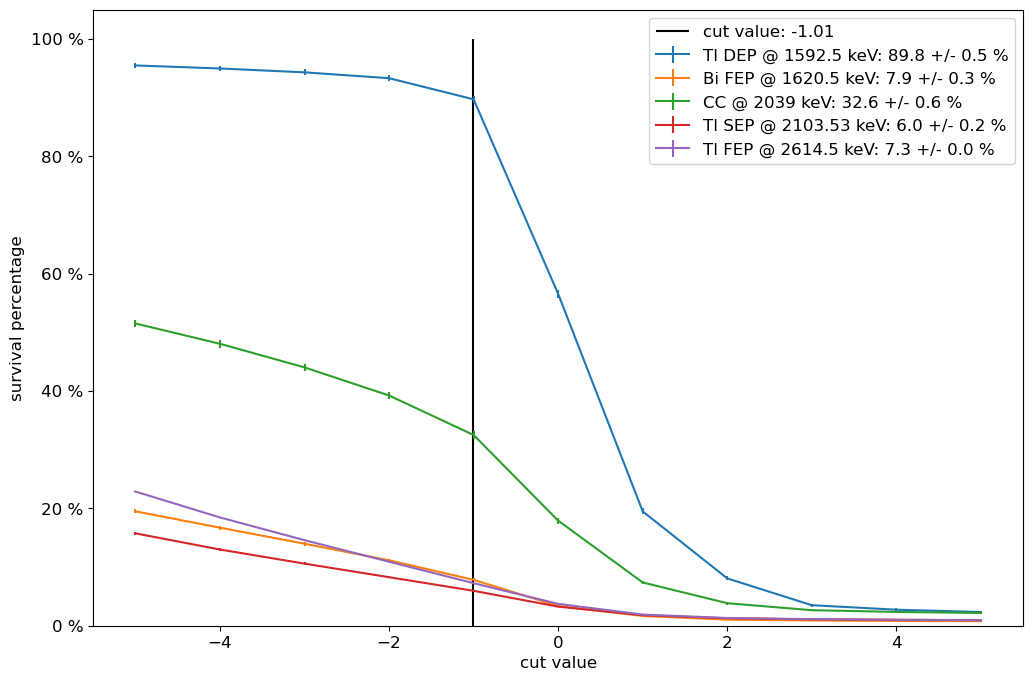

In [24]:

df['aoe']['survival_fractions']

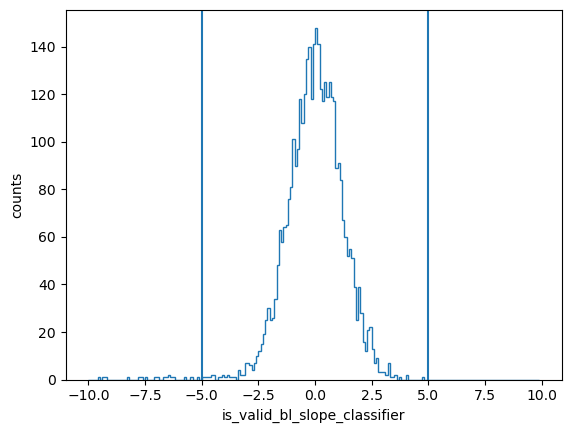

In [25]:
df['qc']['is_valid_bl_slope']

In [26]:
# vado a vedere i file par

In [27]:
detector = "V06649A"

file_par = f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1/generated/par/hit/{detector}/c1/am_HS1_lat_dlt/char_data-{detector}-am_HS1_lat_dlt-r001-20221128T151735Z-par_hit.yaml"


In [28]:
with open(file_par, "r") as f:
    par = yaml.safe_load(f)


In [29]:
par['pars']['operations']['is_valid_bl_slope_classifier'].keys()

dict_keys(['expression', 'parameters'])

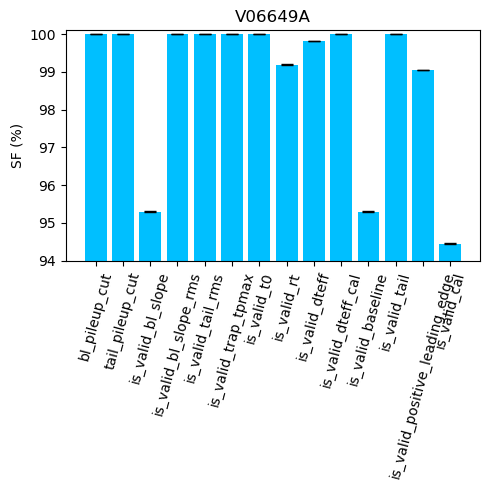

In [30]:
plt.figure(figsize=(5, 5))

labels = []
values = []
errors = []

for v in par['results']['qc'].keys():
    labels.append(v)
    values.append(par['results']['qc'][v]['sf_cal'])
    errors.append(par['results']['qc'][v]['sf_cal_err'])

plt.bar(
    labels,
    values,
    yerr=errors,
    color = 'deepskyblue',
    capsize=4
)

plt.ylim(94,100.1)
plt.title(f"{detector}")
plt.ylabel("SF (%)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [31]:
par['results']['ecal']['cuspEmax_ctc_cal']["eres_quadratic"]

{'function': 'FWHMQuadratic',
 'module': 'pygama.pargen.energy_cal',
 'expression': '(a+b*x+c*x**2)**(0.5)',
 'parameters': {'a': 0.3668847296425957,
  'b': 0.0018363062718645255,
  'c': 1.6725563061164954e-08},
 'uncertainties': {'a': 0.3259544309530559,
  'b': 0.04084772032244412,
  'c': 0.0009225751334279852},
 'cov': [[0.49576714474381867, -0.00831238794733294, -2.366361086922042e-07],
  [-0.00831238794733294, 0.0001395903041051132, 2.9627770312371785e-10],
  [-2.366361086922042e-07, 2.9627770312371785e-10, 6.175082759107743e-11]],
 'csqr': [5.388867388592355e-08, -2],
 'p_val': nan}

In [32]:
(par['results']['ecal']['cuspEmax_ctc_cal']["eres_quadratic"]['parameters']['a']+ 2039 * par['results']['ecal']['cuspEmax_ctc_cal']["eres_quadratic"]['parameters']['b'] + 2039**2 * par['results']['ecal']['cuspEmax_ctc_cal']["eres_quadratic"]['parameters']['c'])  **0.5

2.0446638104192045

In [33]:
par['results']['ecal'].keys()

dict_keys(['cuspEmax_ctc_cal', 'zacEmax_ctc_cal', 'trapEmax_ctc_cal', 'trapEftp_ctc_cal', 'monitoring_parameters'])

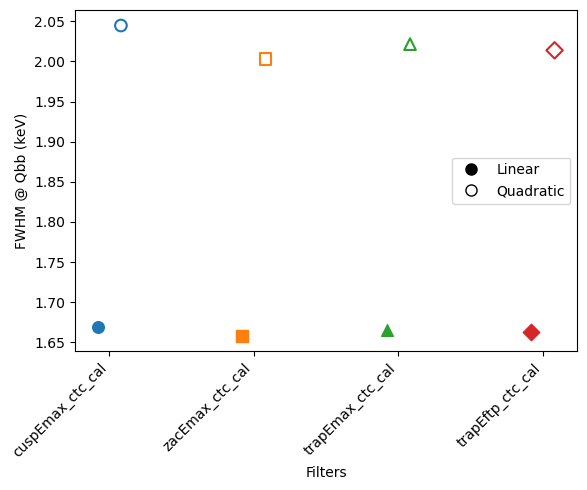

In [34]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(6, 5))

filters = list(par['results']['ecal'].keys())[:-1]

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']

for i, fltr in enumerate(filters):

    lin = par['results']['ecal'][fltr]["eres_linear"]['parameters']
    quad = par['results']['ecal'][fltr]["eres_quadratic"]['parameters']

    Qbb = 2039

    res_lin = (lin['a'] + Qbb * lin['b'])**0.5
    res_quad = (
        quad['a']
        + quad['b'] * Qbb
        + quad['c'] * Qbb**2
    )**0.5

    color = f'C{i}'
    marker = markers[i % len(markers)]

    # Linear: pieno
    plt.scatter(
        i - 0.08,
        res_lin,
        color=color,
        marker=marker,
        s=70
    )

    # Quadratic: vuoto
    plt.scatter(
        i + 0.08,
        res_quad,
        facecolors='none',
        edgecolors=color,
        marker=marker,
        s=70,
        linewidth=1.5
    )

plt.xticks(
    range(len(filters)),
    filters,
    rotation=45,
    ha='right'
)

plt.xlabel('Filters')
plt.ylabel('FWHM @ Qbb (keV)')

# Legenda manuale nera
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor='black',
        markeredgecolor='black',
        markersize=8,
        label='Linear'
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor='none',
        markeredgecolor='black',
        markersize=8,
        label='Quadratic'
    )
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()